# Couverture de taux d'un corporate : pricing d'un swap payeur de fixe et DV01

**Le cas client :** une entreprise a emprunté 50 M€ sur 5 ans à Euribor + marge. Elle veut se couvrir contre une hausse des taux avec un swap où elle **paie le fixe et reçoit l'Euribor**, mais hésite sur la maturité et le taux.

**Ce que fait ce notebook :**
1. Valorise le swap du point de vue du client (payeur de fixe) et calcule son DV01.
2. Reconstruit une courbe EUR par bootstrapping à partir de taux swap de marché.
3. Donne le taux fixe proposé et le DV01 pour chaque maturité (3, 5, 7, 10 ans).
4. Simule des chocs de taux parallèles et des déformations de la courbe.

## 1. Moteur de valorisation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

TAU = 0.25   # paiements trimestriels

def payment_dates(T, tau=TAU):
    """Dates de paiement : 0.25, 0.50, ..., T"""
    return np.arange(1, int(T / tau) + 1) * tau

def swap_value_payer(N, c, curve, dates, tau=TAU):
    """Valeur pour le client payeur de fixe : il reçoit le variable et paie le fixe"""
    df = np.exp(-curve * dates)
    pv_fixed = N * c * tau * df.sum()     # ce qu'il paie
    pv_float = N * (1 - df[-1])           # ce qu'il reçoit (approximation au pair)
    return pv_float - pv_fixed

def par_rate(curve, dates, tau=TAU):
    """Taux fixe qui rend le swap nul à la signature"""
    df = np.exp(-curve * dates)
    return (1 - df[-1]) / (tau * df.sum())

def dv01(N, c, curve, dates, bump=1e-4):
    """Gain du client payeur de fixe si toute la courbe monte de 1 bp"""
    return swap_value_payer(N, c, curve + bump, dates) - swap_value_payer(N, c, curve, dates)

## 2. Courbe EUR par bootstrapping
Taux swap EUR de marché (en %). À compléter avec les maturités intermédiaires (Bloomberg `EUSA1..EUSA10 Curncy`) d'une même date.

In [2]:
MARKET_DATE = "25/09/2026"
market = {0.25: 2.607,   # Euribor 3 mois
          5:    3.65,    # swap EUR 5 ans
          10:   3.71}    # swap EUR 10 ans

def bootstrap(market, max_T=10):
    pillars = np.array(sorted(market))
    rates   = np.array([market[p] for p in pillars]) / 100
    years   = np.arange(1, max_T + 1)
    swap    = np.interp(years, pillars, rates)
    df = []
    for s in swap:
        # un swap au pair vaut 0 : s * somme(DF) + DF_final = 1
        df.append((1 - s * sum(df)) / (1 + s))
    return years, -np.log(np.array(df)) / years   # taux zéro-coupon continus

years, zero = bootstrap(market)

def curve_at(dates, shift=0.0):
    t = np.concatenate(([0.25], years))
    z = np.concatenate(([market[0.25] / 100], zero))
    return np.interp(dates, t, z) + shift

## 3. Quelle maturité proposer au client ?

In [3]:
N = 50_000_000
print("Maturité | Taux fixe proposé | DV01 du client")
for T in [3, 5, 7, 10]:
    d  = payment_dates(T)
    cv = curve_at(d)
    p  = par_rate(cv, d)
    print(f"{T:>5} ans | {p:>15.3%} | {dv01(N, p, cv, d):>10,.0f} €")

Maturité | Taux fixe proposé | DV01 du client
    3 ans |          3.172% |     14,363 €
    5 ans |          3.600% |     22,967 €
    7 ans |          3.624% |     31,026 €
   10 ans |          3.659% |     42,015 €


## 4. Scénarios de marché sur le swap 5 ans signé au taux de marché

Swap client : 5 ans, taux fixe 3.600%, notionnel 50 M€

Hausse parallèle +50 bp                :   +1,134,816 €
Baisse parallèle -50 bp                :   -1,162,669 €
Pentification (court -25, long +25)    :      -32,489 €
Aplatissement (court +25, long -25)    :      +32,433 €

Pitch client : « Ce swap vous expose à 22,967 € par point de base de mouvement des taux. »


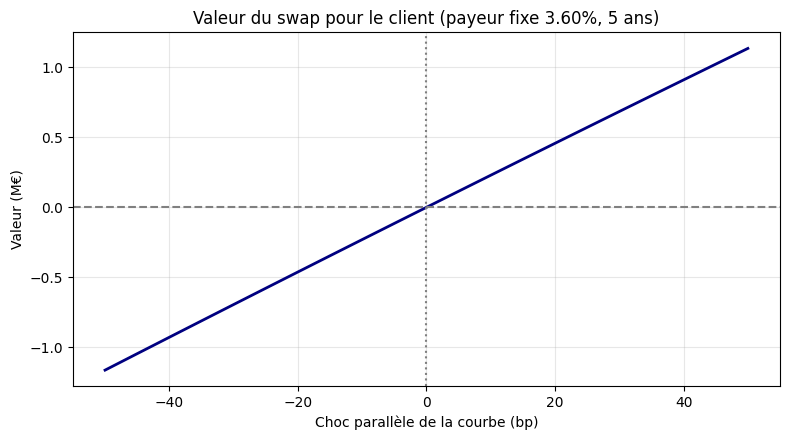

In [4]:
T_client = 5
d_client = payment_dates(T_client)
c_client = par_rate(curve_at(d_client), d_client)

def pivot_shift(dates, short_bp, long_bp, t_short=0.25, t_long=10):
    w = np.clip((dates - t_short) / (t_long - t_short), 0, 1)
    return (short_bp + (long_bp - short_bp) * w) * 1e-4

scenarios = {"Hausse parallèle +50 bp": (50, 50), "Baisse parallèle -50 bp": (-50, -50),
             "Pentification (court -25, long +25)": (-25, 25), "Aplatissement (court +25, long -25)": (25, -25)}
print(f"Swap client : {T_client} ans, taux fixe {c_client:.3%}, notionnel {N/1e6:.0f} M€\n")
for name, (s, l) in scenarios.items():
    v = swap_value_payer(N, c_client, curve_at(d_client) + pivot_shift(d_client, s, l), d_client)
    print(f"{name:<38} : {v:>+12,.0f} €")

d0 = dv01(N, c_client, curve_at(d_client), d_client)
print(f"\nPitch client : « Ce swap vous expose à {d0:,.0f} € par point de base de mouvement des taux. »")

shifts = np.arange(-50, 51, 5)
values = [swap_value_payer(N, c_client, curve_at(d_client, s * 1e-4), d_client) for s in shifts]
plt.figure(figsize=(8, 4.5))
plt.plot(shifts, np.array(values) / 1e6, color="navy", lw=2)
plt.axhline(0, color="gray", ls="--"); plt.axvline(0, color="gray", ls=":")
plt.title(f"Valeur du swap pour le client (payeur fixe {c_client:.2%}, {T_client} ans)")
plt.xlabel("Choc parallèle de la courbe (bp)"); plt.ylabel("Valeur (M€)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Conclusions
- **Le client est payeur de fixe :** sa couverture prend de la valeur quand les taux montent, ce qui compense le surcoût de son prêt. Combiné au prêt, il paie un taux fixe + sa marge, quoi qu'il arrive.
- **Le DV01 croît avec la maturité** (environ 14 k€ à 3 ans, 23 k€ à 5 ans, 42 k€ à 10 ans) : se couvrir plus longtemps protège plus, mais expose davantage la valeur de marché du swap.
- **Un swap 5 ans est surtout exposé au niveau des taux**, très peu à la pente de la courbe.
- **Limites :** courbe construite sur peu de points (interpolation linéaire), une seule courbe pour projeter et actualiser, jambe variable approximée au pair.